In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import shutil
import os


In [6]:

RTOBSPATH = "/Net/Groups/BSI/work_scratch/ppapastefanou/data/Fluxnet_detail/eval_processed"

df_sap23 = pd.read_csv(os.path.join(RTOBSPATH, "Sapflow2023.csv"))
df_sap23['date'] = pd.to_datetime(df_sap23['date'])

In [29]:
df_sap24 = pd.read_csv(os.path.join("/Net/Groups/BSI/work_scratch/ppapastefanou/data/Fluxnet_detail/raw", "DE-Hai_forcing_30min_20230101_20241231.csv"))
df_sap24['date'] = pd.to_datetime(df_sap24["Unnamed: 0"])
df_sap24

,Unnamed: 0,PA_44m,WS_44m,WD_44m,SW_IN_44m,SW_OUT_44m,LW_IN_44m,LW_OUT_44m,SW_DIF_IN_44m,PPFD_IN_44m,...,H2Omolefrac,Ji_Acpl,Ji_Fasy,Ji_Frex,Ji_all,Ji_sd_Acpl,Ji_sd_Fasy,Ji_sd_Frex,Ji_sd_all,date
0,2023-01-01 00:00:00+00:00,957.021233,5.376667,237.666442,0.166333,0.166333,286.400000,375.266667,4.347958,1.414667,...,8.1945,0.051171,3.163716,-0.280247,1.609104,0.375360,6.994730,0.111217,5.964259,2023-01-01 00:00:00+00:00
1,2023-01-01 00:30:00+00:00,957.086333,6.370333,243.499061,0.332667,0.332667,287.400000,374.266667,4.423292,3.395000,...,8.2351,0.665952,3.080894,-0.232123,1.822095,0.451126,6.603261,0.133317,5.625121,2023-01-01 00:30:00+00:00
2,2023-01-01 01:00:00+00:00,957.247833,5.311000,231.165277,0.499000,0.499000,286.700000,374.966667,3.166381,1.414667,...,8.1424,1.091570,3.420620,0.895345,2.700569,0.000000,6.726588,2.127885,5.596810,2023-01-01 01:00:00+00:00
3,2023-01-01 01:30:00+00:00,957.338700,5.093667,229.266667,0.425074,0.425074,283.800000,371.966667,0.459000,0.849000,...,8.2168,1.611769,3.302063,-0.170720,2.071606,0.189163,6.554446,0.144741,5.578499,2023-01-01 01:30:00+00:00
4,2023-01-01 02:00:00+00:00,957.378733,5.041000,224.681427,0.785821,0.000000,281.166667,369.600000,0.546333,2.263500,...,8.4542,0.555607,3.691919,0.470125,2.710078,0.300337,6.871760,2.051987,5.647080,2023-01-01 02:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35081,2024-12-31 20:30:00+00:00,964.597567,6.996000,247.699629,0.664417,0.013600,301.566667,301.700000,2.344444,0.112333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31 20:30:00+00:00
35082,2024-12-31 21:00:00+00:00,964.535133,7.463667,242.328874,0.000000,0.029400,302.300000,302.366667,5.131534,0.093000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31 21:00:00+00:00
35083,2024-12-31 21:30:00+00:00,963.909067,9.580000,243.498834,0.000000,0.004500,302.433333,302.566667,5.135704,0.113000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31 21:30:00+00:00
35084,2024-12-31 22:00:00+00:00,963.762000,8.496667,246.167003,0.000000,0.000000,302.866667,303.066667,5.128892,0.080333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31 22:00:00+00:00


In [42]:
df_ji = df_sap24[["date","Ji_Fasy"]].dropna()
df_ji = df_ji[(df_ji['date'] >= '2023-05-01')]
df_ji = df_ji[(df_ji['date'] <= '2023-12-31') | (df_ji['date'] >= '2024-05-1') ]
df_ji['date'] = df_ji['date'].dt.tz_localize(None)
df_ji

,date,Ji_Fasy
5760,2023-05-01 00:00:00,4.430749
5761,2023-05-01 00:30:00,4.301841
5762,2023-05-01 01:00:00,4.164321
5763,2023-05-01 01:30:00,4.424417
5764,2023-05-01 02:00:00,4.028929
...,...,...
28997,2024-08-27 02:30:00,8.916333
28998,2024-08-27 03:00:00,8.994872
28999,2024-08-27 03:30:00,9.126641
29000,2024-08-27 04:00:00,10.584576


In [37]:
import matplotlib.pyplot as plt

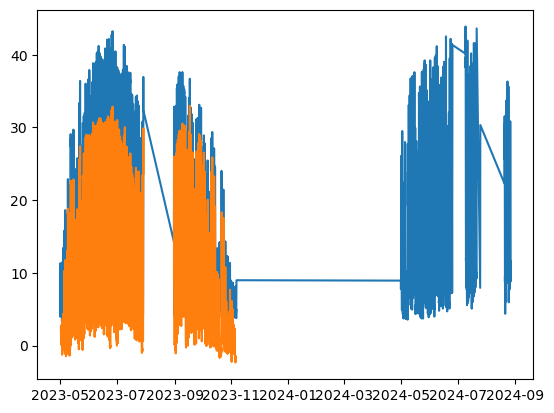

In [38]:
plt.plot(df_ji["date"], df_ji["Ji_Fasy"])
plt.plot(df_sap23["date"], df_sap23["J0.5"])

In [43]:
df_ji.to_csv("/Net/Groups/BSI/work_scratch/ppapastefanou/data/Fluxnet_detail/eval_processed/Sapflow2023-2024.csv")